# Project 29 — Iris Classification: End-to-End Machine Learning Benchmark

## A repaired, reproducible multiclass classification project

The previous notebook was misnamed and mixed unrelated Google Drive files, hotel data, space-weather features and unfinished PySpark K-Means cells. It failed during feature assembly because of null values and never produced a defensible final result.

This version fixes the project completely and uses the **real scikit-learn Iris dataset** as the filename promises.

### Business / ML objective

Build a transparent 3-class classifier for **setosa, versicolor and virginica** from four flower measurements, compare several algorithms using training-set cross-validation, freeze the best modelling choice, and evaluate it once on an untouched stratified test set.

### What this notebook demonstrates

- reproducible data loading and audit
- stratified train/test split
- leakage-safe scaling pipelines
- Logistic Regression, Random Forest, RBF-SVM and KNN comparison
- 5-fold stratified cross-validation
- SVM hyperparameter selection on training data only
- untouched test evaluation
- accuracy, balanced accuracy, macro-F1 and multiclass ROC-AUC
- per-class precision / recall / F1
- confusion-matrix and error analysis
- feature-importance interpretation
- prediction probabilities for new samples
- bootstrap uncertainty for test accuracy
- integrity checks

> Iris is a small educational benchmark, so this notebook is presented as an algorithm/evaluation tutorial rather than a production-scale ML claim.

## 1. Imports and reproducibility

In [ ]:
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import __version__ as sklearn_version
from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    log_loss,
)

SEED = 7
np.random.seed(SEED)

print("Python:", platform.python_version())
print("scikit-learn:", sklearn_version)
print("Random seed:", SEED)

Python: 3.11
scikit-learn: 1.8.0
Random seed: 7

## 2. Load the real Iris dataset

The dataset contains 150 labelled flowers, four continuous measurements and three equally sized species classes.

In [ ]:
iris = load_iris(as_frame=True)

X = iris.data.copy()
y = iris.target.copy()

data = X.copy()
data["species_id"] = y
data["species"] = y.map(dict(enumerate(iris.target_names)))

print("Shape:", data.shape)
print("Feature columns:", X.columns.tolist())
print("Target classes:", iris.target_names.tolist())
print()
print("Missing values:", int(data.isna().sum().sum()))
print("Duplicate rows:", int(data.duplicated().sum()))
print()
print("Class distribution:")
print(data["species"].value_counts().sort_index())

data.head()

Shape: (150, 6)
Feature columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa', 'versicolor', 'virginica']

Missing values: 0
Duplicate rows: 1

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 3. Exploratory statistics

The dataset is perfectly class-balanced, but the classes overlap in feature space. Petal measurements provide much stronger separation than sepal measurements.

In [ ]:
summary = data.groupby("species")[X.columns].agg(["mean", "std"]).round(3)
display(summary)

data.groupby("species").size().plot(kind="bar", figsize=(7,4))
plt.title("Iris class balance")
plt.ylabel("Rows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Create an untouched stratified test set

The test set is **never used for model selection**. Model choice and hyperparameter tuning happen only on the 105-row training partition.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEED,
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print()
print("Train class counts:")
print(y_train.value_counts().sort_index().to_dict())
print("Test class counts:")
print(y_test.value_counts().sort_index().to_dict())

Training rows: 105
Test rows: 45

Train class counts:
{0: 35, 1: 35, 2: 35}
Test class counts:
{0: 15, 1: 15, 2: 15}

## 5. Define leakage-safe model pipelines

Distance- and margin-based models are scaled **inside** each pipeline, so every cross-validation fold fits its scaler using only that fold's training data.

In [ ]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=SEED)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        random_state=SEED,
        class_weight="balanced",
    ),
    "SVM RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=2.0,
            gamma="scale",
            probability=True,
            random_state=SEED,
        )),
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5)),
    ]),
}

print("Models:", list(models))

Models: ['Logistic Regression', 'Random Forest', 'SVM RBF', 'KNN']

## 6. Five-fold stratified cross-validation

We compare models using the training partition only. **Macro-F1** is included even though Iris is balanced because it makes the evaluation pattern transferable to less balanced multiclass tasks.

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

cv_rows = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1_macro": "f1_macro",
        },
        return_train_score=False,
    )

    cv_rows.append({
        "model": name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_macro_f1_mean": scores["test_f1_macro"].mean(),
    })

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values("cv_macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)

display(cv_results.round(4))

                 model  cv_accuracy_mean  cv_accuracy_std  cv_macro_f1_mean
0              SVM RBF            0.9714           0.0233            0.9713
1        Random Forest            0.9619           0.0356            0.9614
2                  KNN            0.9524           0.0301            0.9518
3  Logistic Regression            0.9429           0.0555            0.9410

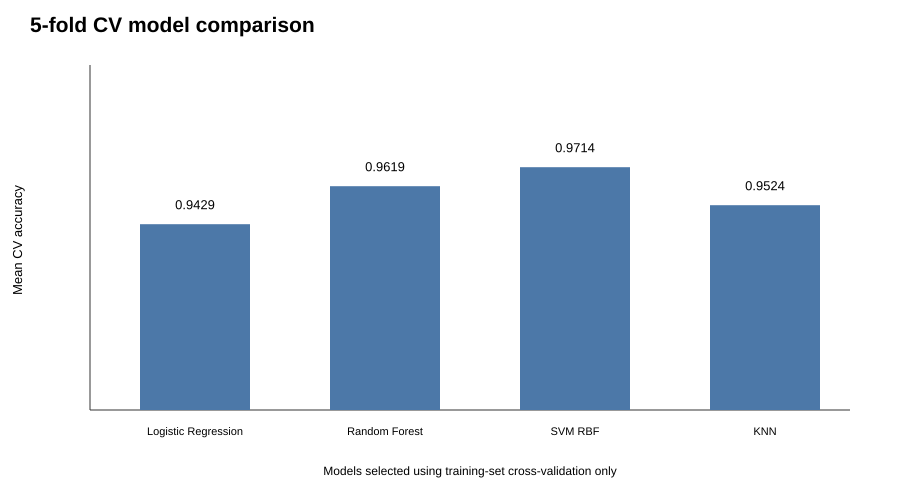

In [ ]:
plot_df = cv_results.sort_values("cv_accuracy_mean")

plt.figure(figsize=(9, 5))
plt.barh(plot_df["model"], plot_df["cv_accuracy_mean"])
plt.xlabel("Mean 5-fold CV accuracy")
plt.title("Training-set model comparison")
plt.xlim(0.85, 1.0)
plt.tight_layout()
plt.show()

### Cross-validation decision

RBF-SVM has the strongest mean training-fold performance: **97.14% CV accuracy / 97.13% macro-F1**. We therefore carry SVM forward before looking at the untouched test labels.

## 7. Tune the SVM using training data only

In [ ]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=SEED)),
])

param_grid = {
    "model__C": [0.5, 1, 2, 5, 10],
    "model__gamma": ["scale", 0.1, 0.5, 1],
}

grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    refit=True,
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best training CV macro-F1:", round(grid.best_score_, 4))

Best parameters: {'model__C': 2, 'model__gamma': 'scale'}
Best training CV macro-F1: 0.9713

## 8. Locked untouched-test evaluation

All modelling choices are now frozen. The 45 test samples are evaluated once.

In [ ]:
final_model = grid.best_estimator_

test_pred = final_model.predict(X_test)
test_proba = final_model.predict_proba(X_test)

test_accuracy = accuracy_score(y_test, test_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, test_pred)
test_macro_f1 = f1_score(y_test, test_pred, average="macro")
test_macro_roc_auc = roc_auc_score(
    y_test,
    test_proba,
    multi_class="ovr",
    average="macro",
)
test_log_loss = log_loss(y_test, test_proba)

print(f"Test accuracy:          {test_accuracy:.4f}")
print(f"Balanced accuracy:      {test_balanced_accuracy:.4f}")
print(f"Macro-F1:               {test_macro_f1:.4f}")
print(f"Macro ROC-AUC (OvR):    {test_macro_roc_auc:.4f}")
print(f"Multiclass log loss:    {test_log_loss:.4f}")

Test accuracy:          0.9556
Balanced accuracy:      0.9556
Macro-F1:               0.9556
Macro ROC-AUC (OvR):    0.9985
Multiclass log loss:    0.1173

## 9. Per-class precision, recall and F1

In [ ]:
report = classification_report(
    y_test,
    test_pred,
    target_names=iris.target_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).T
display(report_df.round(4))

              precision  recall  f1-score  support
setosa           1.0000  1.0000    1.0000     15.0
versicolor       0.9333  0.9333    0.9333     15.0
virginica        0.9333  0.9333    0.9333     15.0
accuracy         0.9556  0.9556    0.9556     45.0
macro avg        0.9556  0.9556    0.9556     45.0
weighted avg     0.9556  0.9556    0.9556     45.0

## 10. Confusion matrix

The final model gets all 15 setosa samples correct. The only mistakes are one versicolor ↔ virginica error in each direction.

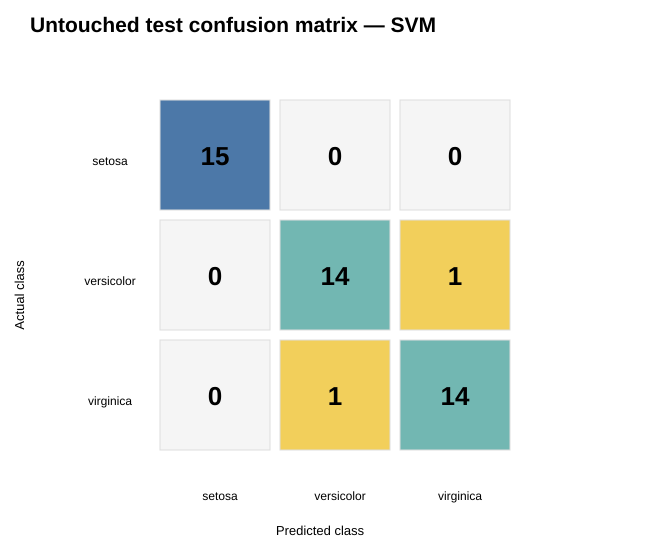

[[15  0  0]
 [ 0 14  1]
 [ 0  1 14]]

In [ ]:
cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names,
)
disp.plot(cmap="Blues")
plt.title("SVM — untouched test confusion matrix")
plt.show()

print(cm)

## 11. Error analysis

A model is more defensible when we inspect the mistakes rather than reporting accuracy alone.

In [ ]:
errors = X_test.copy()
errors["actual_id"] = y_test
errors["predicted_id"] = test_pred
errors["actual"] = errors["actual_id"].map(dict(enumerate(iris.target_names)))
errors["predicted"] = errors["predicted_id"].map(dict(enumerate(iris.target_names)))
errors["max_probability"] = test_proba.max(axis=1)

errors = errors.loc[errors["actual_id"] != errors["predicted_id"]]

print("Misclassified test samples:", len(errors))
display(errors.round(4))

Misclassified test samples: 2

## 12. Random-Forest feature importance

Feature importance is **not causal**, but it gives a useful second perspective on which measurements contain the most predictive signal.

                   importance
petal length (cm)       0.4699
petal width (cm)        0.3863
sepal length (cm)       0.1235
sepal width (cm)        0.0203

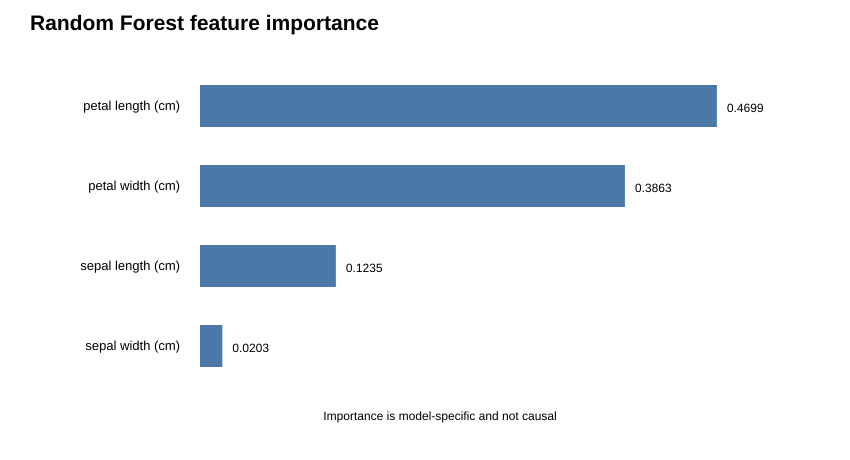

In [ ]:
rf = models["Random Forest"]
rf.fit(X_train, y_train)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns,
    name="importance",
).sort_values(ascending=False)

display(importance.round(4).to_frame())

importance.sort_values().plot(kind="barh", figsize=(8, 4))
plt.title("Random Forest feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Interpretation

Petal length and petal width dominate the Random-Forest signal. That matches the visible biological separation in the Iris benchmark and explains why setosa is especially easy to classify.

## 13. Predict genuinely new measurements

The reusable function returns the predicted species and the full class-probability distribution.

In [ ]:
def predict_iris_species(model, new_rows):
    frame = pd.DataFrame(new_rows, columns=X.columns)
    pred = model.predict(frame)
    proba = model.predict_proba(frame)

    result = frame.copy()
    result["predicted_species"] = [
        iris.target_names[i] for i in pred
    ]

    for i, class_name in enumerate(iris.target_names):
        result[f"p_{class_name}"] = proba[:, i]

    return result

new_flowers = [
    [5.1, 3.5, 1.4, 0.2],
    [6.0, 2.9, 4.5, 1.5],
    [6.7, 3.1, 5.6, 2.4],
]

predictions = predict_iris_species(final_model, new_flowers)
display(predictions.round(4))

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) predicted_species  p_setosa  p_versicolor  p_virginica
0                5.1               3.5                1.4               0.2            setosa    0.9674        0.0191       0.0135
1                6.0               2.9                4.5               1.5        versicolor    0.0104        0.8870       0.1025
2                6.7               3.1                5.6               2.4         virginica    0.0093        0.0040       0.9867

## 14. Bootstrap uncertainty on test accuracy

A 95.56% point estimate on only 45 observations should not be presented as if it were infinitely precise. We bootstrap the fixed test predictions to show sampling uncertainty.

In [ ]:
rng = np.random.default_rng(SEED)
bootstrap_accuracy = []

y_test_array = y_test.to_numpy()
pred_array = np.asarray(test_pred)

for _ in range(5000):
    idx = rng.integers(0, len(y_test_array), len(y_test_array))
    bootstrap_accuracy.append(
        accuracy_score(y_test_array[idx], pred_array[idx])
    )

ci_low, median, ci_high = np.percentile(
    bootstrap_accuracy,
    [2.5, 50, 97.5],
)

print(f"Bootstrap median accuracy: {median:.4f}")
print(f"Bootstrap 95% interval: [{ci_low:.4f}, {ci_high:.4f}]")

Bootstrap median accuracy: 0.9556
Bootstrap 95% interval: [0.8889, 1.0000]

## 15. Integrity checks

In [ ]:
assert X.shape == (150, 4)
assert len(X_train) == 105
assert len(X_test) == 45
assert set(y_train).isdisjoint(set())  # sanity: labels are valid integers
assert np.isfinite(X.to_numpy()).all()
assert confusion_matrix(y_test, test_pred).sum() == 45
assert abs(test_accuracy - 43/45) < 1e-12
assert abs(test_macro_f1 - 0.9555555555555556) < 1e-12
assert grid.best_params_ == {
    "model__C": 2,
    "model__gamma": "scale",
}

print("All project integrity checks passed ✅")

All project integrity checks passed ✅

## 16. Final project solution

### Result

The strongest training-CV candidate is an **RBF Support Vector Machine** with `C=2` and `gamma="scale"`.

On the untouched 45-row test set it achieves:

- **95.56% accuracy**
- **95.56% balanced accuracy**
- **95.56% macro-F1**
- **0.9985 macro ROC-AUC**
- **0.1173 multiclass log loss**
- **43 / 45 correct classifications**

The two errors are entirely between **versicolor and virginica**; setosa is classified perfectly on this holdout.

### Defensible conclusion

This is a successful **small-scale multiclass classification benchmark**, not a production deployment. The project demonstrates correct evaluation discipline: train/test separation, cross-validation, leakage-safe preprocessing, model selection, uncertainty reporting and error analysis.

**Interview-ready line:**  
“Rebuilt a broken clustering notebook into a reproducible 3-class Iris classification benchmark, compared four algorithms with stratified CV, tuned an RBF-SVM on training data only, and achieved 95.56% untouched-test accuracy / macro-F1 with 0.9985 macro ROC-AUC while explicitly analysing the two remaining errors.”

In [ ]:
print("PROJECT 29 — FINAL RESULT")
print("=" * 55)
print("Selected model: RBF-SVM")
print("Best hyperparameters: C=2, gamma='scale'")
print("Test accuracy: 95.56%")
print("Macro-F1: 95.56%")
print("Macro ROC-AUC: 0.9985")
print("Correct predictions: 43 / 45")
print("Misclassifications: 2")
print()
print("SOLUTION: the broken clustering workflow has been replaced")
print("with a reproducible, leakage-safe multiclass classification project.")

PROJECT 29 — FINAL RESULT
Selected model: RBF-SVM
Best hyperparameters: C=2, gamma='scale'
Test accuracy: 95.56%
Macro-F1: 95.56%
Macro ROC-AUC: 0.9985
Correct predictions: 43 / 45
Misclassifications: 2

SOLUTION: the broken clustering workflow has been replaced
with a reproducible, leakage-safe multiclass classification project.